# (28) poisson + BALLS16: (32, 24.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'BALLS16')

cfg_vae['n_latents'] = 32 + 1
cfg_vae['seq_len'] = 32
cfg_tr['kl_beta'] = 24.0

cfg_tr['epochs'] = 2_000
cfg_tr['grad_clip'] = 10_000

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |   8.8 K    |
|     ———     |    ———     |
|    layer    |   8.8 K    |
+-------------+------------+

poisson_BALLS16_t-32_z-[33]_cl-10,10_<grad|lin>
b400-ep2000-lr(0.002)_beta(24:0.1)_temp(0.01:0.5)_gr(10000)_(2025_03_01,10:43)

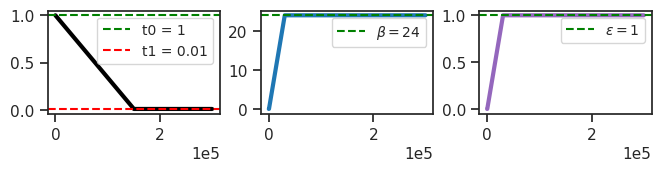

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

300000

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=256, latent_dim=33, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),)

In [8]:
tr.train()

epoch # 2000, avg loss: -552.128790: 100%|█| 2000/2000 [7:05:29<00:00, 12.76s/it


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0451], device='cuda:1', grad_fn=<ExpBackward0>),)

In [10]:
print(tr.model.layer.n_exp)

tensor([123, 144, 161, 173, 183, 194, 205, 215, 219, 223, 225, 226, 226, 228,
        228, 228, 229, 229, 229, 228, 229, 231, 229, 230, 230, 231, 232, 232,
        232, 233, 232, 233], device='cuda:1', dtype=torch.int32)

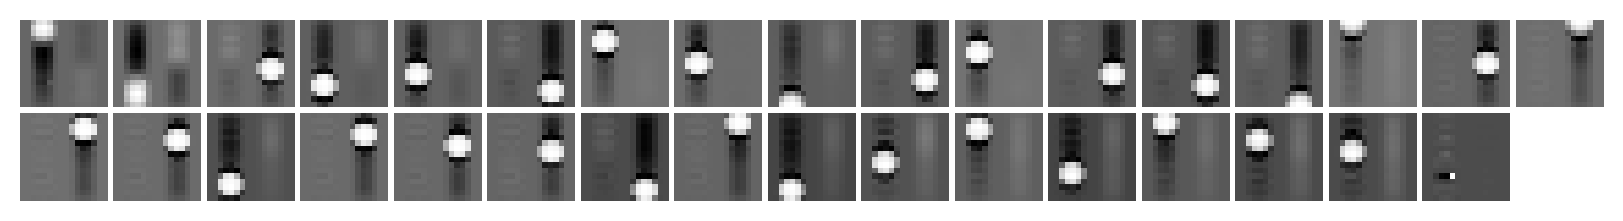

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=2);

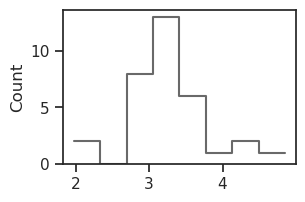

In [14]:
histplot(u0, color='dimgrey')
plt.show()

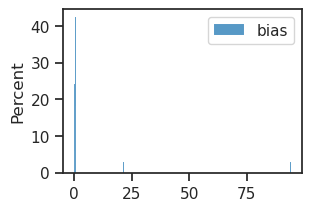

In [15]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

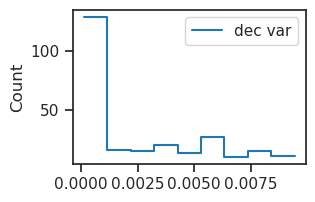

In [16]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

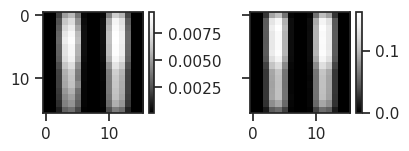

In [17]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:03<00:00,  1.84s/it]


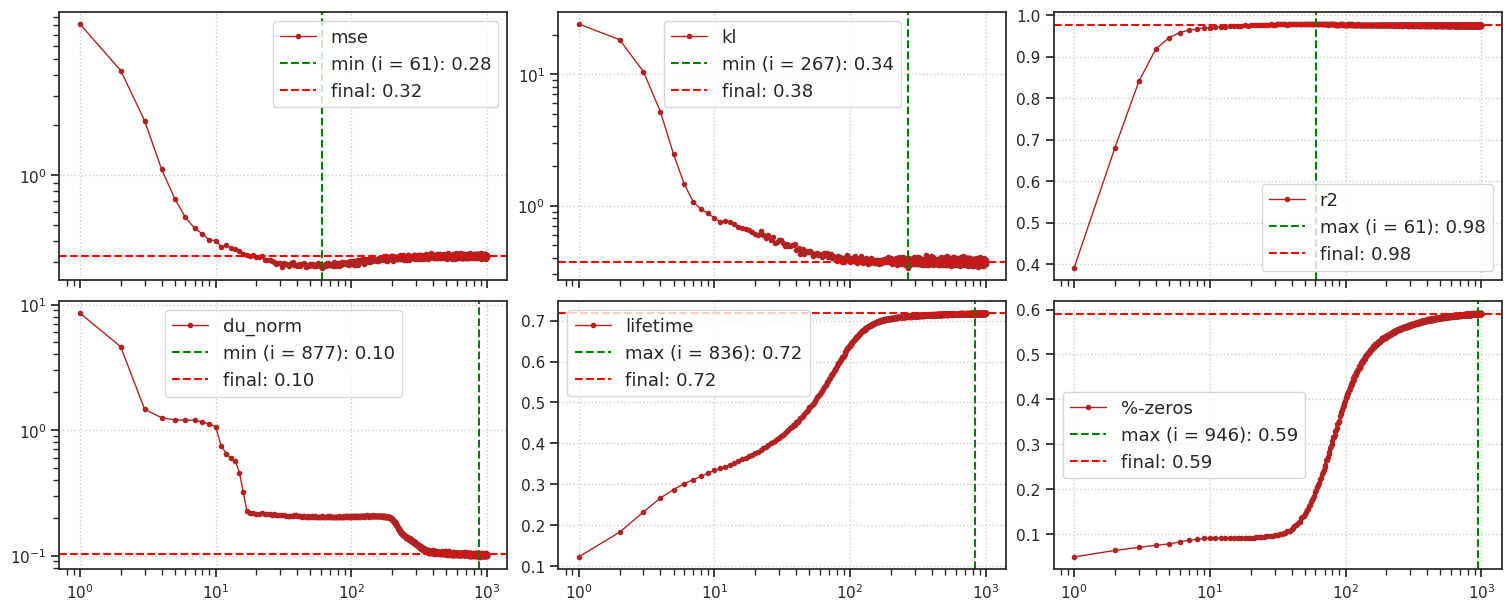

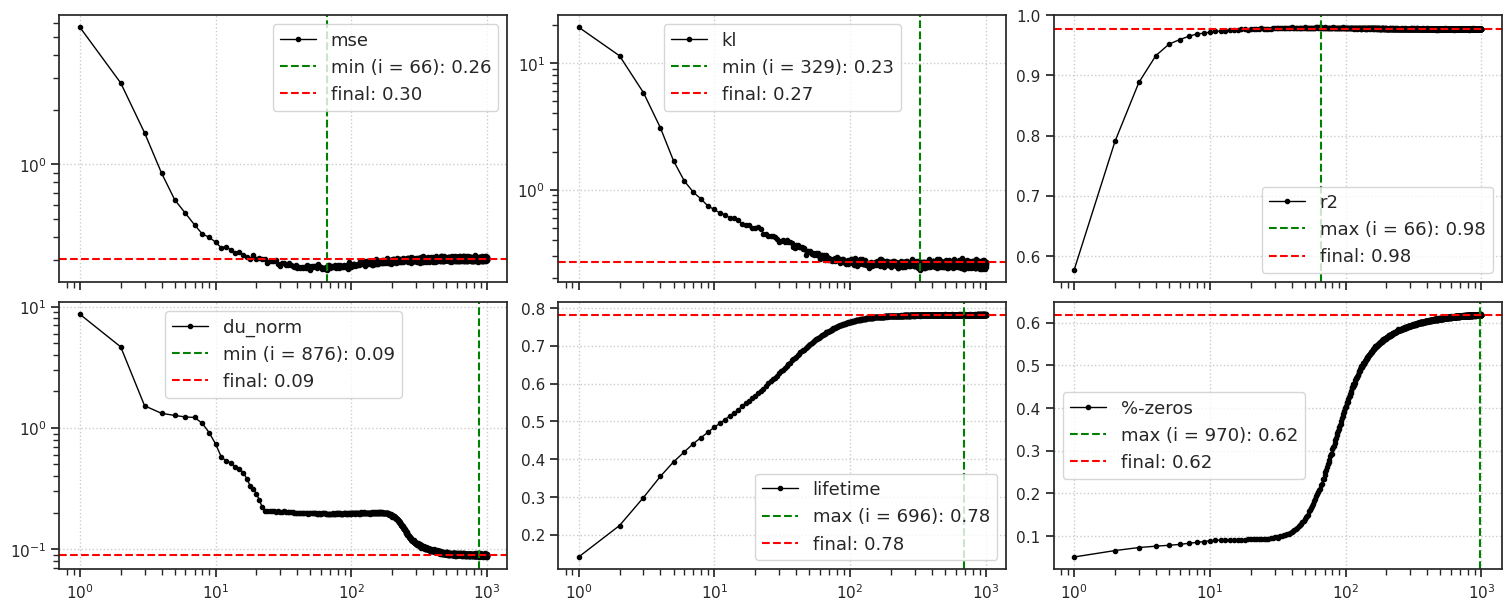

CPU times: user 12.3 s, sys: 44 ms, total: 12.3 s
Wall time: 12.3 s


In [18]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

## r2 score test

In [24]:
from base.helper import find_weight_concentrations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

In [25]:
%%time


seq_total = 1000
selection = ['u', 'samples', 'r2']

kws_dl = dict(
    batch_size=1000,
    drop_last=False,
    shuffle=False,
)

results = {}
for item in ['trn', 'vld', 'tst']:
    # create data loader without shuffle
    ds = getattr(tr, f"dl_{item}").dataset
    dl = torch.utils.data.DataLoader(ds, **kws_dl)
    data = collections.defaultdict(list)
    for x, g in tqdm(iter(dl)):
        output = tr.model.xtract_ftr(
            feeder=tr.get_feeder(x),
            seq=range(seq_total),
            return_extras=True,
        ).stack()
        data['g'].append(g)
        for key in selection:
            data[key].append(output[key][:, -1])
        data['lamb'].append(output['u'][:, -1].exp())
    data = {
        k: tonp(torch.cat(v)) for
        k, v in data.items()
    }
    results[item] = data

100%|███████████████████████████████████████████| 50/50 [01:39<00:00,  1.99s/it]

CPU times: user 4min 22s, sys: 268 ms, total: 4min 22s
Wall time: 4min 22s


In [26]:
var = 'lamb'

lr = LinearRegression().fit(
    X=results['trn'][var],
    y=results['trn']['g'][:, [1, 3]],
)
r2 = {
    name: r2_score(
        y_true=d['g'][:, [1, 3]],
        y_pred=lr.predict(d[var]),
        multioutput='raw_values')
    for name, d in results.items()
}
corr = {
    name: 1 - np.diag(sp_dist.cdist(
        XA=d['g'][:, [1, 3]].T,
        XB=lr.predict(d[var]).T,
        metric='correlation',
    )) for name, d in results.items()
}

In [27]:
print(f"r2:", r2, '\nCorr:', corr)

r2:
{
    'trn': array([0.99704844, 0.99672139]),
    'vld': array([0.9970676 , 0.99686331]),
    'tst': array([0.98138892, 0.97739296])
}

Corr:
{
    'trn': array([0.99852313, 0.99835935]),
    'vld': array([0.99853275, 0.99843135]),
    'tst': array([0.99078738, 0.98932852])
}

## output

In [19]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

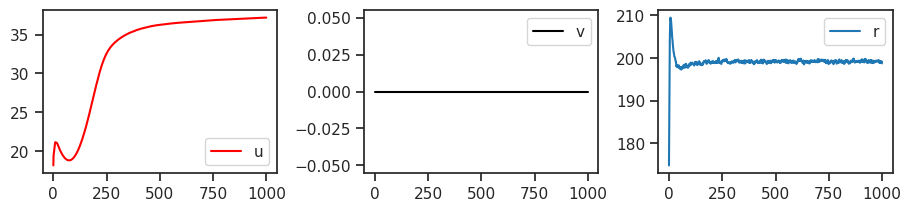

In [20]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

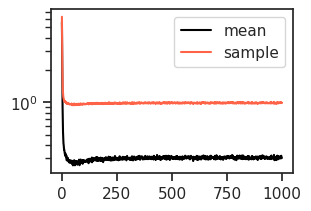

(tensor([0.3150, 0.3168, 0.3080, 0.3046, 0.3023], device='cuda:1'),
 tensor([1.0013, 1.0012, 0.9908, 0.9817, 0.9859], device='cuda:1'))

In [21]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

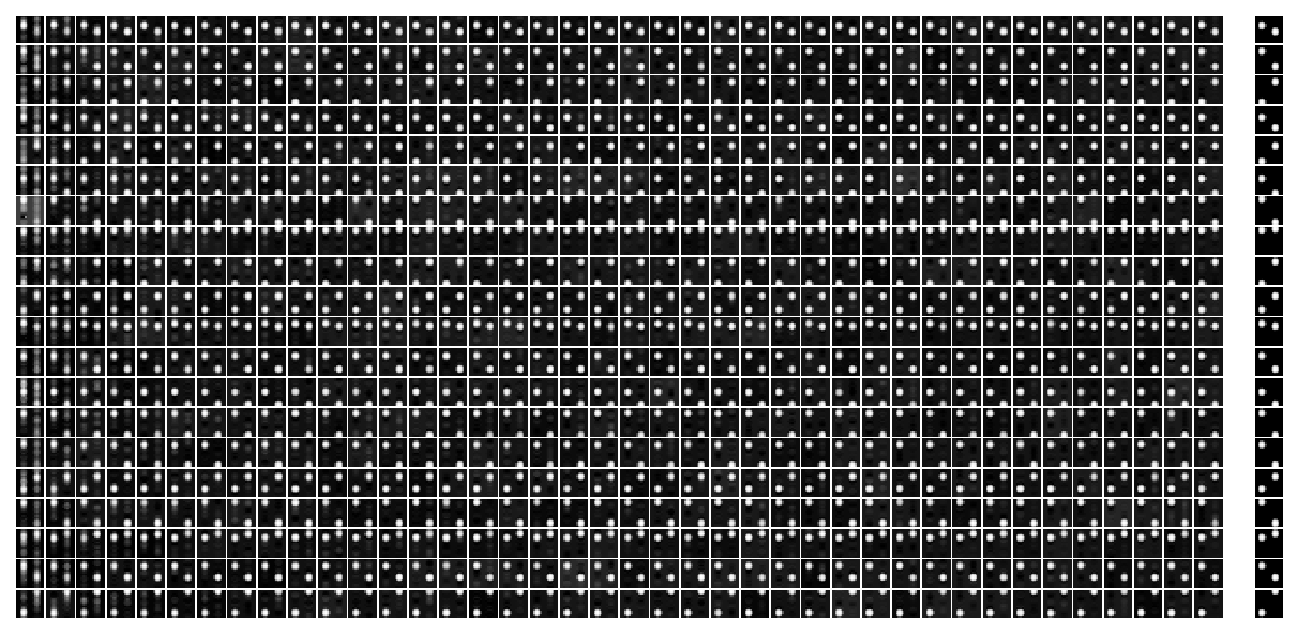

In [22]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

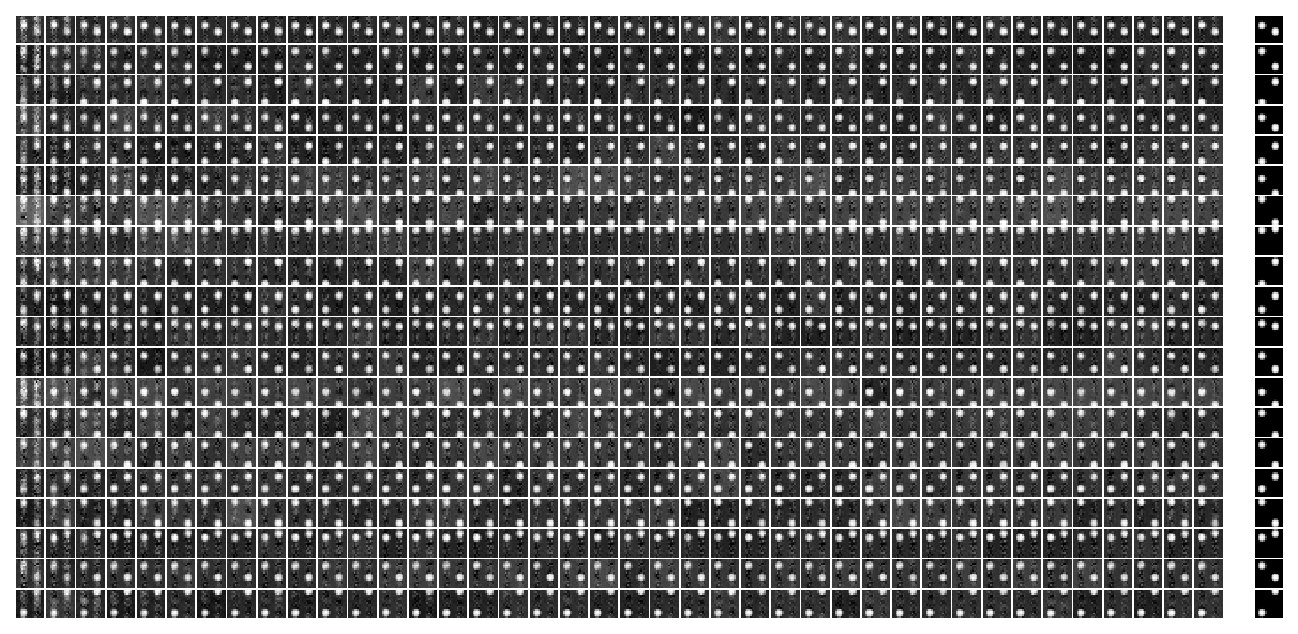

In [23]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)